**Our Problem Statement is to analyze the dataset of properties in Islamabad and then building a model to predict its price using location, Area(Sq.ft), bedrooms, baths...**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('property_with_Feature_Engineering.csv')

In [4]:
df.head()

,property_id,location_id,page_url,property_type,price,price_bin,location,city,province_name,locality,...,area_marla,area_sqft,purpose,bedrooms,date_added,year,month,day,agency,agent
0,347795,8,https://www.zameen.com/Property/lahore_model_t...,House,220000000,Very High,Model Town,Lahore,Punjab,"Model Town, Lahore, Punjab",...,120.0,32670.12,For Sale,0,07-17-2019,2019,7,17,Real Biz International,Usama Khan
1,482892,48,https://www.zameen.com/Property/lahore_multan_...,House,40000000,Very High,Multan Road,Lahore,Punjab,"Multan Road, Lahore, Punjab",...,20.0,5445.02,For Sale,5,10-06-2018,2018,10,6,Khan Estate,mohsinkhan and B
2,555962,75,https://www.zameen.com/Property/eden_eden_aven...,House,9500000,Low,Eden,Lahore,Punjab,"Eden, Lahore, Punjab",...,9.0,2450.26,For Sale,3,07-03-2019,2019,7,3,Shahum Estate 2,"Babar Hameed, Raja Omar"
3,562843,3821,https://www.zameen.com/Property/gulberg_2_gulb...,House,125000000,Very High,Gulberg,Lahore,Punjab,"Gulberg, Lahore, Punjab",...,20.0,5445.02,For Sale,8,04-04-2019,2019,4,4,NaN,NaN
4,686990,3522,https://www.zameen.com/Property/allama_iqbal_t...,House,21000000,High,Allama Iqbal Town,Lahore,Punjab,"Allama Iqbal Town, Lahore, Punjab",...,11.0,2994.76,For Sale,6,04-04-2019,2019,4,4,NaN,NaN


In [5]:
df = df[df['city'] == 'Islamabad']
df.head(2)

,property_id,location_id,page_url,property_type,price,price_bin,location,city,province_name,locality,...,area_marla,area_sqft,purpose,bedrooms,date_added,year,month,day,agency,agent
396,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,High,G-10,Islamabad,Islamabad Capital,"G-10, Islamabad, Islamabad Capital",...,4.0,1089.00,For Sale,2,02-04-2019,2019,2,4,NaN,NaN
397,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,Medium,E-11,Islamabad,Islamabad Capital,"E-11, Islamabad, Islamabad Capital",...,5.6,1524.61,For Sale,3,05-04-2019,2019,5,4,NaN,NaN


In [6]:
df.shape

(40195, 24)

## EDA

There are so much unnecessary columns which will not be used in model and they can impact models performance so we will be dropping those columns

In [7]:
# dropping unnecessary columns
col_names = ["location_id","page_url","province_name","locality","area_marla","year","month","day","agency","agent","latitude","longitude","property_id","property_type","price_bin","purpose","date_added","city","area"]
df = df.drop(col_names, axis=1)

In [8]:
df = df.reset_index()
df = df.drop("index",axis=1)
df.head()

,price,location,baths,area_sqft,bedrooms
0,10000000,G-10,2,1089.00,2
1,6900000,E-11,3,1524.61,3
2,16500000,G-15,6,2178.01,5
3,70000000,F-10,6,8167.53,6
4,43500000,Bani Gala,4,10890.04,4


In [9]:
df.sample(5)

,price,location,baths,area_sqft,bedrooms
10969,80000,F-7,0,7078.53,2
31678,50000,D-12,0,1089.00,0
27034,55000,Swan Garden,0,2722.51,5
1670,87000,F-10,0,5445.02,3
7906,55000000,Bhara kahu,6,21780.08,6


In [10]:
df.isnull().sum()

price        0
location     0
baths        0
area_sqft    0
bedrooms     0
dtype: int64

In [11]:
df.shape

(40195, 5)

In [12]:
df['bedrooms'].unique()

array([ 2,  3,  5,  6,  4,  8,  7,  0,  1, 10,  9, 11, 12, 16, 18, 15, 21,
       14])

## Data Cleaning

As You can see in the above cell that there are some properties which have bedrooms even greater than 10...This could be possible that some of them could be typo error while others can be having other errors in them as well like very less baths or no baths...Lets inspect the properties that are having bedrooms more than 12

In [13]:
df[df['bedrooms']>12]

,price,location,baths,area_sqft,bedrooms
3735,140000000,F-11,0,10890.04,16
6419,550000,F-7,10,13068.05,18
19183,115000000,E-11,0,6534.02,16
27874,90000000,G-14,0,7078.53,15
28784,300000,G-14,0,6534.02,21
31229,90000000,G-13,0,7078.53,15
33849,650000,F-8,0,21780.08,14
33854,650000,F-8,14,21780.08,14
37650,90000000,G-14,0,7078.53,15


Notice how some of them are having no baths and some are having very less number of baths as compared to their bedrooms...

In [14]:
df['baths'].unique()

array([ 2,  3,  6,  4,  8,  7,  5,  0,  1, 10,  9, 11, 12, 13, 14])

In the above cell, You will see that there are up to 14 numbers of baths which is quite uncommon and may be a typo error or other kind of error.

In [15]:
df = df.drop(df[(df['baths']==0) & (df['bedrooms'] > 4)].index)
df

,price,location,baths,area_sqft,bedrooms
0,10000000,G-10,2,1089.00,2
1,6900000,E-11,3,1524.61,3
2,16500000,G-15,6,2178.01,5
3,70000000,F-10,6,8167.53,6
4,43500000,Bani Gala,4,10890.04,4
...,...,...,...,...,...
40190,70000,I-8,0,3375.91,3
40191,40000,I-8,0,3375.91,2
40192,160000,G-10,6,5445.02,6
40193,25000,DHA Defence,2,735.08,2


In the above cell we have dropped those indexes that are having no baths and having bedrooms greater than 4 cause they can probably be a typo error.

In [16]:
df.drop(df[(df['bedrooms']==0) | (df['baths']==0)].index, inplace=True)

We have also dropped those rows where have 0 bedrooms and 0 baths.

In [17]:
df[df["baths"] > df["bedrooms"]].head(10)

,price,location,baths,area_sqft,bedrooms
2,16500000,G-15,6,2178.01,5
16,13500000,DHA Defence,5,2722.51,3
23,55000000,G-11,7,3811.51,6
35,4500000,Ghauri Town,3,1361.25,2
43,14000000,F-17,6,1905.76,4
45,32500000,Korang Town,9,3267.01,7
47,30000000,Bahria Town,7,2722.51,6
49,21000000,Bahria Town,6,2722.51,5
55,14500000,Ghauri Town,5,1905.76,4
57,850000000,F-6,10,26136.10,9


There are some homes that are having more number of baths as compared to its bedrooms which is quite uncommon...

## Outliers Detections and Removals

In [18]:
df['price_per_sqft'] = df['price'] / df['area_sqft']
df.head()

,price,location,baths,area_sqft,bedrooms,price_per_sqft
0,10000000,G-10,2,1089.00,2,9182.736455
1,6900000,E-11,3,1524.61,3,4525.747568
2,16500000,G-15,6,2178.01,5,7575.722793
3,70000000,F-10,6,8167.53,6,8570.522545
4,43500000,Bani Gala,4,10890.04,4,3994.475686


We have added a new column for feature engineering so that outliers can detected and removed easily.


In [20]:
df['location'].nunique()

207

In [21]:
df['location'] = df['location'].apply(lambda x: x.strip())
location_status = df.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_status.head(30)

location
DHA Defence                       3051
E-11                              2495
G-13                              2016
G-11                              1676
I-8                               1657
F-11                              1643
Bahria Town                       1304
G-15                              1147
F-10                              1108
F-8                               1074
F-7                               1058
I-10                               925
Ghauri Town                        811
Soan Garden                        647
F-6                                646
Bani Gala                          619
PWD Housing Scheme                 545
G-10                               493
B-17                               409
G-9                                406
CBR Town                           347
Gulberg                            317
FECHS                              284
H-13                               283
Pakistan Town                      277
D-12            

In [22]:
len(location_status[location_status <= 12])

109

Notice that there are 109 locations that are having properties less than 12 so we can categorize them as others which will help us in dimensionality reduction in our machine learning model.

In [23]:
locations_less_than_12 = location_status[location_status <= 12]
df['location'] = df['location'].apply(lambda x:'others' if x in locations_less_than_12 else x)

In [24]:
df['location'].nunique()

99

Firstly there were 207 unique locations and now we are having only 99 unique locations after dimensionality reduction

In [25]:
df[df['area_sqft'] / df['bedrooms'] < 400]

,price,location,baths,area_sqft,bedrooms,price_per_sqft
27,4500000,Garden Town,4,1279.58,4,3.516779e+03
28,6800000,others,4,1089.00,4,6.244261e+03
36,12500000,I-16,5,2178.01,6,5.739184e+03
41,46500000,G-13,9,2967.54,9,1.566954e+04
54,14000000,G-13,5,1089.00,5,1.285583e+04
...,...,...,...,...,...,...
40155,33000,D-17,3,163.35,3,2.020202e+02
40165,36000,I-10,2,0.00,2,inf
40166,90000,D-17,9,163.35,9,5.509642e+02
40193,25000,DHA Defence,2,735.08,2,3.400990e+01


In the above cell we assume that on  minimum a bedroom must be more than 400 sq.ft so those that were not following that rule in our data we will be removing them as they will be considered as outliers...

In [26]:
df.drop(df[df['area_sqft'] / df['bedrooms'] < 500].index, inplace = True)

In [27]:
df['price_per_sqft'].describe()

count     22959.000000
mean       2939.926988
std        5281.798560
min           0.000413
25%          16.834965
50%          31.339089
75%        5064.279611
max      167793.638868
Name: price_per_sqft, dtype: float64

Standard Deviation is too high in the above cell, We will be reducing it.


In [28]:
# removing price_per_sqft outliers 
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key,subdf in df.groupby('location'):
        m = np.mean(subdf['price_per_sqft'])
        std = np.std(subdf['price_per_sqft'])
        reduced_df = subdf[(subdf['price_per_sqft'] > (m-std)) & (subdf['price_per_sqft'] <= (m+std))]
        df_out = pd.concat([df_out,reduced_df], ignore_index=True)
    return df_out

In [29]:
df = remove_pps_outliers(df)
df.shape

(18357, 6)

In [30]:
import matplotlib.pyplot as plt
import matplotlib
def plot_scatter_chart(df, location):
    bedroom_2 = df[(df['location'] == location) & (df['bedrooms'] == 2)]
    bedroom_3 = df[(df['location'] == location) & (df['bedrooms'] == 3)]
    matplotlib.rcParams["figure.figsize"] = (10,5)
    plt.scatter(bedroom_2['area_sqft'], bedroom_2['price']/100000, color='blue', label="2 Bedroom", s=50)
    plt.scatter(bedroom_3['area_sqft'], bedroom_3['price']/100000, marker='+', color="green", label="3 Bedroom", s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price")
    plt.title(location)
    plt.legend()

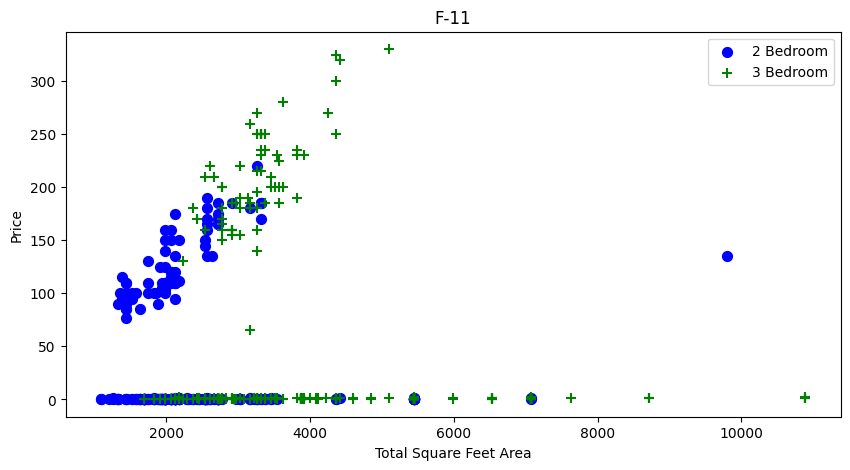

In [31]:
plot_scatter_chart(df, "F-11")

Notice in the above graph that there are some properties having 3 bedrooms still in less price than 2 bedrooms properties in a specfied location. Now they can also be considered as outliers and we should also remove them so that they cannot affect our model performance

In [32]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby("location"):
        bhk_stats = {}
        for bedroom, bedroom_df in location_df.groupby("bedrooms"):
            bhk_stats[bedroom] = {
                'mean' : np.mean(bedroom_df["price_per_sqft"]),
                'std' : np.std(bedroom_df["price_per_sqft"]),
                'count': bedroom_df.shape[0]
            }
        for bedroom, bedroom_df in location_df.groupby("bedrooms"):
            stats = bhk_stats.get(bedroom - 1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bedroom_df[bedroom_df['price_per_sqft'] < (stats['mean'])].index.values)
    return df.drop(exclude_indices, axis="index") 

In [33]:
df = remove_bhk_outliers(df)
df.shape

(7022, 6)

In [34]:
df.groupby('location')['location'].agg('count').sort_values(ascending=False).head(40)

location
DHA Defence                       728
I-10                              495
E-11                              390
F-7                               386
Bahria Town                       353
F-8                               342
F-11                              304
F-6                               274
F-10                              227
G-15                              220
G-11                              204
PWD Housing Scheme                198
Bani Gala                         189
Gulberg                           149
Ghauri Town                       144
I-8                               139
G-9                               117
G-13                              116
Lehtarar Road                     108
Pakistan Town                     103
others                             94
E-7                                91
B-17                               86
FECHS                              81
Bhara kahu                         78
CBR Town                           70
Nat

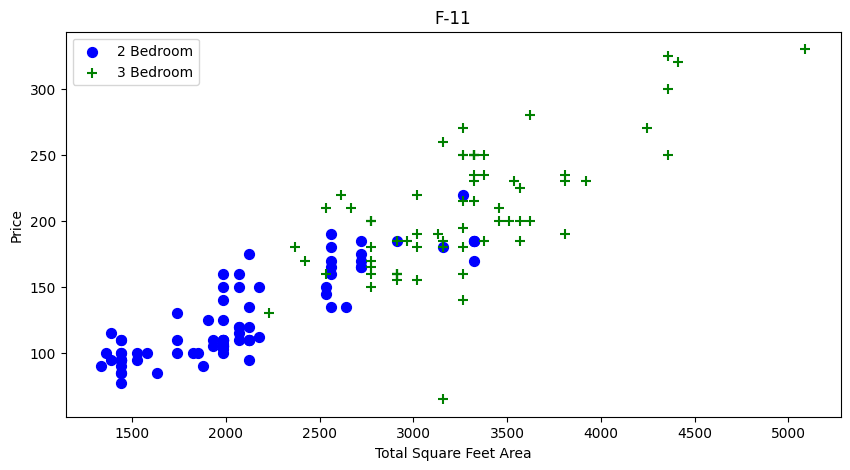

In [35]:
plot_scatter_chart(df, "F-11")

In [36]:
df[df['baths'] > df['bedrooms']]

,price,location,baths,area_sqft,bedrooms,price_per_sqft
15,35000,7th Avenue,3,1905.76,2,18.365377
16,35000,7th Avenue,3,1905.76,2,18.365377
18,400000,7th Avenue,6,5445.02,4,73.461622
20,300000,7th Avenue,7,7078.53,6,42.381681
23,700000,7th Avenue,7,21780.08,6,32.139460
...,...,...,...,...,...,...
18311,16000000,others,6,2722.51,5,5876.929745
18317,15500000,others,6,2722.51,5,5693.275690
18342,5300000,others,3,1361.25,2,3893.480257
18344,85000000,others,9,27225.10,7,3122.118927


In [38]:
df[df['baths'] > (df['bedrooms'] + 2)]

,price,location,baths,area_sqft,bedrooms,price_per_sqft
410,49500000,Bahria Town,10,5445.02,7,9090.875699
754,10600000,Bahria Town,10,1524.61,3,6952.597714
1275,75000000,Bani Gala,7,27225.10,4,2754.810818
1366,7500000,Bhara kahu,8,1905.76,3,3935.437831
1545,18000,Chatha Bakhtawar,5,1361.25,2,13.223140
1555,25000,Chatha Bakhtawar,6,1361.25,2,18.365473
1661,300000,D-12,13,6534.02,10,45.913542
1702,11700000,D-17,8,2531.93,4,4620.980833
1747,15000000,DHA Defence,8,3267.01,4,4591.354174
2418,31500000,DHA Defence,8,5445.02,5,5785.102718


In [39]:
df = df.drop(df[df['baths'] > (df['bedrooms'] + 2)].index)
df.shape

(6993, 6)

In [40]:
df1 = df.drop("price_per_sqft", axis=1)

In [41]:
dummies = pd.get_dummies(df1['location'])
dummies.head(3)

,7th Avenue,9th Avenue,Ali Pur,Alipur Farash,Arsalan Town,B-17,Bahria Town,Bani Gala,Bhara kahu,Blue Area,...,Simly Dam Road,Soan Garden,Swan Garden,Taramrri,Tarlai,Tarnol,Thanda Pani,The Springs,Zaraj Housing Scheme,others
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


We have removed the Price per sqft feature because it does not required anymore and also we have added dummies of locations.

In [42]:
df1 = pd.concat([df1, dummies.drop('others', axis=1)], axis="columns")
df1 = df1.drop("location", axis=1)
df1.head()
df1.shape

(6993, 102)

In [43]:
df1.head()

,price,baths,area_sqft,bedrooms,7th Avenue,9th Avenue,Ali Pur,Alipur Farash,Arsalan Town,B-17,...,Shehzad Town,Simly Dam Road,Soan Garden,Swan Garden,Taramrri,Tarlai,Tarnol,Thanda Pani,The Springs,Zaraj Housing Scheme
0,90000,2,1742.41,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1000000,8,10890.04,8,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,17000,1,1361.25,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,20000,2,1361.25,2,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,65000,2,2722.51,3,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Model Evaluation

In [70]:
x = df1.drop('price', axis=1) 
x.head()

,baths,area_sqft,bedrooms,7th Avenue,9th Avenue,Ali Pur,Alipur Farash,Arsalan Town,B-17,Bahria Town,...,Shehzad Town,Simly Dam Road,Soan Garden,Swan Garden,Taramrri,Tarlai,Tarnol,Thanda Pani,The Springs,Zaraj Housing Scheme
0,2,1742.41,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,8,10890.04,8,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,1361.25,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2,1361.25,2,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2,2722.51,3,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [71]:
y = df1['price'] 
y.head()

0      90000
1    1000000
2      17000
3      20000
4      65000
Name: price, dtype: int64

In [72]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)

In [73]:

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)

-4.926409829833253

Note that our linear regression model performs with low accuracy, We will improve this accuracy...

In [74]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
cross_val_score(LinearRegression(), x, y, cv=cv)

array([ 0.27936594,  0.19961703, -7.1134006 ,  0.32848474,  0.25202484])

In [75]:
# importing other regression models to find the best performing model using GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [54]:
def find_best_model_using_gridsearchcv(X, y):
    algos = {
        'linear_regression': {
            'model':LinearRegression(),
            'params': {'fit_intercept': [True, False],'positive': [True, False]}
    
        },'decision_tree_regressor':{
            'model': DecisionTreeRegressor(),
            'params': {'criterion': ['mse','friedman_mse'], 'splitter':['best','random']}
        },'lasso': {
            'model':Lasso(),
            'params': {'alpha':[1,2], 'selection':['random','cyclic']}
        }
    }
    
    
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    scores = []
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], return_train_score=False, n_jobs=-1, cv=cv)
        gs.fit(X, y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_ ,
            'best_params': gs.best_params_
        })
        
    return pd.DataFrame(scores, columns=['model','best_score','best_params'])

In [55]:
find_best_model_using_gridsearchcv(x, y)

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py"

,model,best_score,best_params
0,linear_regression,-0.894178,"{'fit_intercept': False, 'positive': True}"
1,decision_tree_regressor,0.600368,"{'criterion': 'friedman_mse', 'splitter': 'ran..."
2,lasso,-1.210779,"{'alpha': 2, 'selection': 'random'}"


In [56]:
dtr = DecisionTreeRegressor(criterion='friedman_mse', splitter='random', random_state=0)
dtr.fit(x, y)

,criterion,'friedman_mse'
,splitter,'random'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [68]:
def predict_price(location, sqft, bedrooms, baths):
    loc_index = np.where(x.columns==location)[0][0]
    
    xx = np.zeros(len(x.columns))
    xx[0] = baths
    xx[1] = sqft
    xx[2] = bedrooms
    if loc_index >= 0:
        xx[loc_index] = 1
    return dtr.predict([xx])[0] / 100000

In [82]:
print(str(int(predict_price('Bahria Town', 1080, 3, 2))) + " Lakhs")

150 Lakhs


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
